# Introduction

Damage to the hippocampus and nearby structures can cause striking memory difficulties. A person may struggle to remember something that just happened while retaining knowledge acquired many years earlier. They may have no recollection of practicing a task, yet improve with repeated practice. These observations show that memory is not a single ability, and that hippocampal damage does not bring all learning to a halt.

Memories of experiences and knowledge that we can consciously retrieve are generally called **explicit, or declarative, memories**. These include **episodic memory**, which concerns particular personal experiences, such as where we met someone yesterday, and **semantic memory**, which concerns facts, concepts, and word meanings, such as knowing that birds have feathers without remembering when we first learned it. In contrast, **implicit, or nondeclarative, memory** does not require conscious recollection. It is expressed through changes in behavior, such as becoming more skilled with practice or recognizing a word more quickly after encountering it before.

Hippocampal damage does not affect these forms of memory equally. A well-known example is patient H.M., whose bilateral medial temporal lobe surgery involved the hippocampus and related structures. After surgery, his ability to form new memories was severely impaired. Difficulty remembering new experiences following an injury is called **anterograde amnesia**. Some learning abilities, however, remained intact. H.M. could gradually improve at tracing a figure viewed in a mirror, even without remembering earlier practice sessions. Remembering an episode of practice and acquiring a skill through practice can therefore come apart.

Damage can also affect memories formed before the injury, a condition called **retrograde amnesia**. In some studies, recently acquired memories were more vulnerable than older ones. This pattern is known as **temporally graded retrograde amnesia**. It suggests that, for at least some memories, the hippocampus is particularly important early on, but that dependence may diminish over time.

**Memory consolidation** refers to the process through which memories become more stable after they are formed. Here, we focus on consolidation at the level of brain systems. In the account we will model, new memories initially depend on the hippocampal system. Through repeated interactions between the hippocampus and neocortex, the neocortex gradually develops connections that can support those memories. This is not a matter of moving an intact memory from one location to another. Rather, the connections supporting memory, and the way they are organized, change over time. The models that follow illustrate how learning could bring about these changes.

# Semantic knowledge network

The semantic knowledge network models learning in the neocortex. It assumes that, as the network learns the attributes of individual concepts, shared attributes gradually shape its internal representations, giving related concepts similar activity patterns. For example, robins and canaries both fly and have feathers. Learning these shared attributes brings their representations closer together.

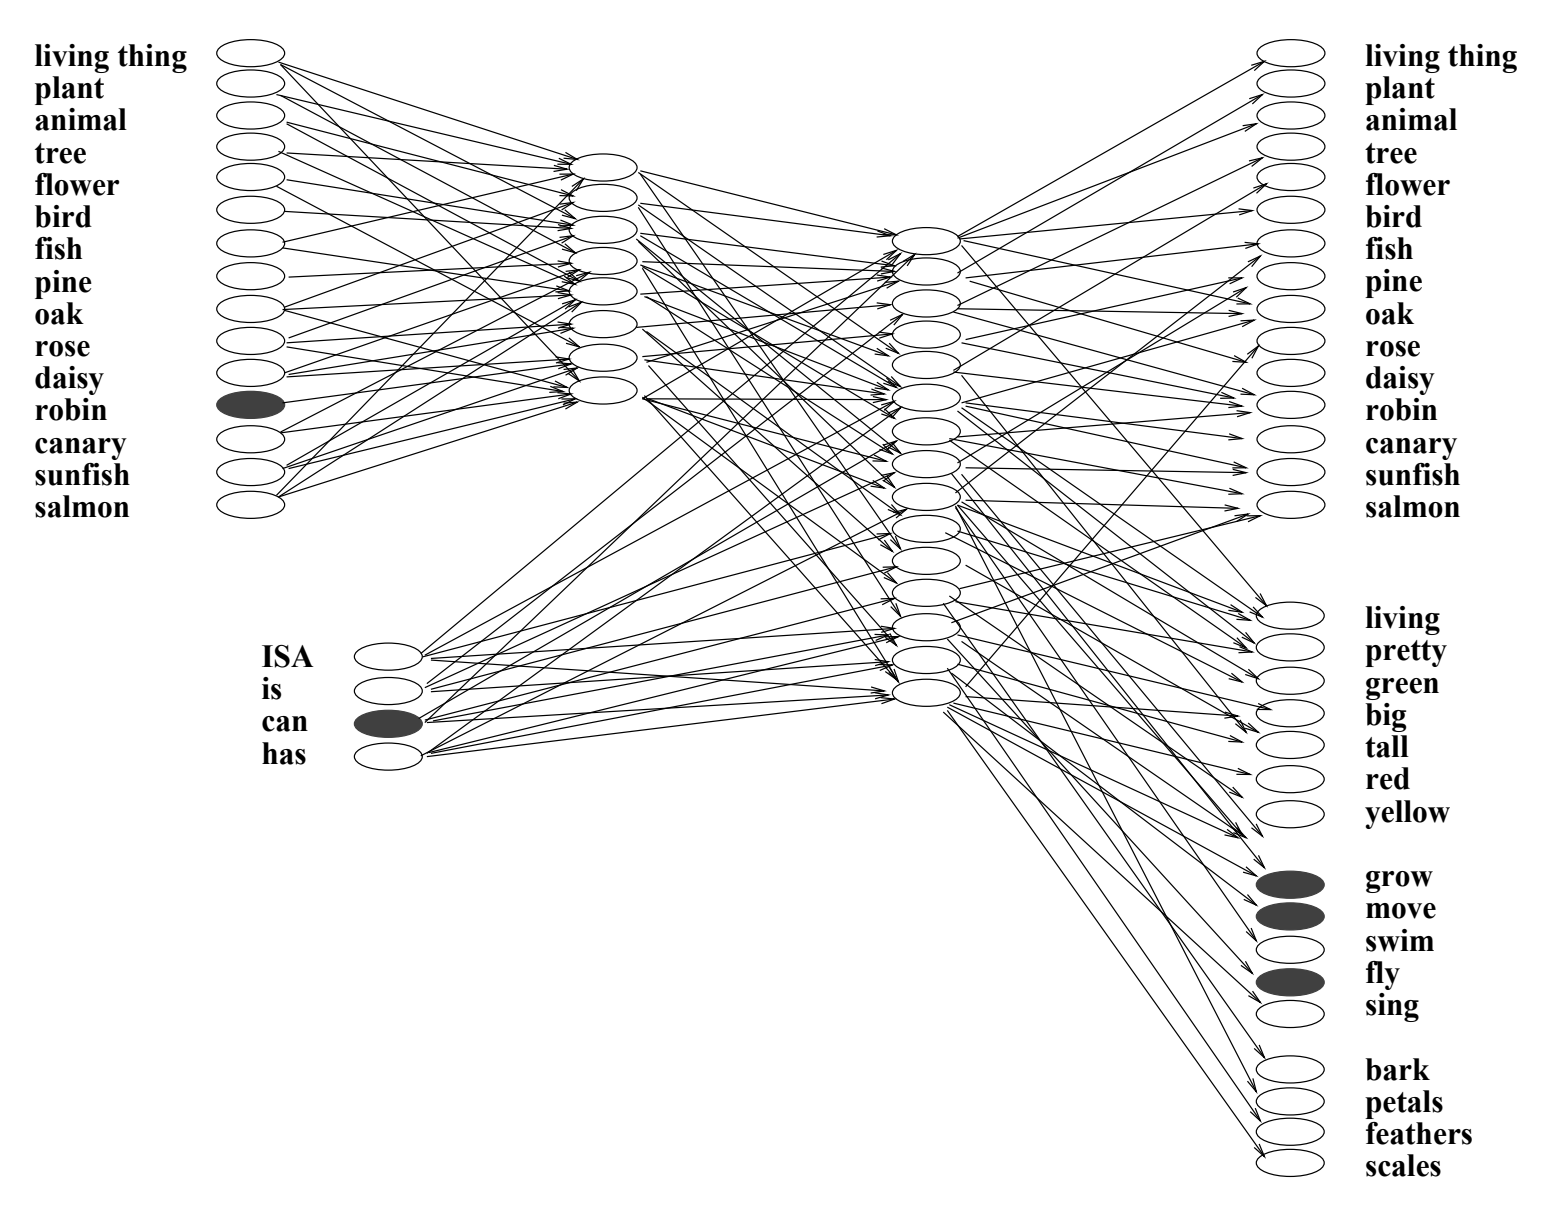

## Setup

In [1]:
# Locate shared data when opened from this notebook folder or the project root.
from pathlib import Path
import os, sys
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / 'data' / 'targets.csv').is_file()), Path.cwd())
os.chdir(project_root)
sys.path.insert(0, str(project_root / 'notebooks' / 'semantic'))

import numpy as np
import torch
from torch import nn
torch.set_num_threads(1)
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit as sigmoid
from scipy.cluster.hierarchy import linkage, dendrogram
from IPython.display import Image, display
from training_view import TrainingView

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

## Plotting helper

In [2]:
# @title Plotting helpers
def plot_clusters(snapshots, indices, labels):
    """Cluster representations using Euclidean distance and average linkage."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
    for ax, (epoch, activity) in zip(axes, snapshots.items()):
        tree = linkage(activity[indices], method='average', metric='euclidean')
        dendrogram(tree, labels=labels, ax=ax, orientation='right',
                   color_threshold=0, above_threshold_color='steelblue')
        ax.set_title(f'Epoch {epoch}')
        ax.set_xlabel('Distance')
        ax.set_xlim(0, 1.5)
    fig.tight_layout()
    plt.show()

## 1. The learning task

Each example combines a **concept** and a **relation**. The concept identifies the object; the relation specifies what to ask about it.

| Relation | Example question | Example answers |
|---|---|---|
| `isa` | What is a robin? | robin, bird, animal, living thing |
| `is` | What is a robin like? | red, living |
| `can` | What can a robin do? | grow, move, fly |
| `has` | What does a robin have? | feathers |

These answers come from a predefined, simplified knowledge system. A question can have several correct answers, including properties inherited from broader categories: a robin can grow because it is a living thing, and move because it is an animal.

To examine whether the network can learn these relationships, we use one-hot inputs: one position is 1 and all others are 0. The concept input has 15 positions, and the relation input has 4.

`targets.csv` contains 60 concept–relation combinations and 31 output attributes. Correct answers have a target value of 0.95; all others have a target of 0.05. The table below shows the `can` targets for two birds.

In [3]:
targets = pd.read_csv('data/targets.csv', index_col=0)
pairs = targets.index.str.split(' | ', regex=False)
concepts = list(dict.fromkeys(pair[0] for pair in pairs))
relations = ['isa', 'is', 'can', 'has']

X = np.eye(len(concepts))[[concepts.index(pair[0]) for pair in pairs]]
R = np.eye(len(relations))[[relations.index(pair[1]) for pair in pairs]]
Y = targets.to_numpy()

X, R, Y = [torch.tensor(a, dtype=torch.float64) for a in (X, R, Y)]
print("Concepts:", X.shape, "Relations:", R.shape, "Targets:", Y.shape)
targets.loc[['robin | can', 'canary | can'], ['grow', 'move', 'swim', 'fly', 'sing']]

Concepts: torch.Size([60, 15]) Relations: torch.Size([60, 4]) Targets: torch.Size([60, 31])


,grow,move,swim,fly,sing
robin | can,0.95,0.95,0.05,0.95,0.05
canary | can,0.95,0.95,0.05,0.95,0.95


## 2. Network structure and training

The diagram above shows **robin + can**. From left to right, the concept input passes through 8 representation units, then joins the relation input at a second hidden layer, which calculates the output activities.

In [4]:
class SemanticNetwork(nn.Module):
    def __init__(self, seed=0):
        super().__init__()
        self.representation = nn.Linear(15, 8, dtype=torch.float64)
        self.hidden = nn.Linear(12, 15, dtype=torch.float64)
        self.output = nn.Linear(15, 31, dtype=torch.float64)
        rng = np.random.default_rng(seed)
        with torch.no_grad():
            for layer in (self.representation, self.hidden, self.output):
                layer.weight.copy_(torch.tensor(rng.uniform(-.5, .5, (layer.in_features, layer.out_features)).T))
                layer.bias.copy_(torch.tensor(rng.uniform(-.5, .5, layer.out_features)))

    def representations(self, x):
        return torch.sigmoid(self.representation(x))

    def forward(self, x, relation):
        combined = torch.cat((self.representations(x), relation), dim=-1)
        hidden = torch.sigmoid(self.hidden(combined))
        return torch.sigmoid(self.output(hidden))

### Learning from one example

The network compares its predictions with the targets using:

$$
L=\frac{1}{2}\sum_k(\hat y_k-y_k)^2
$$

Here, $\hat y_k$ is the prediction of output unit $k$, and $y_k$ is its target. Backpropagation computes the gradient of the loss with respect to each connection weight; the weights are then adjusted to reduce the error.

The code computes the error signals for all three layers before updating the weights. The learning rate is 0.1, with no momentum. Each example produces one weight update.

One pass through all 60 examples is an epoch. We shuffle the examples each epoch and train for 500 epochs. All layers use sigmoid activations. Initial weights and biases are sampled uniformly between −0.5 and 0.5.

We record each concept's representation at the end of every epoch.

In [5]:
def learn_one(model, optimizer, x, relation, target):
    optimizer.zero_grad()
    loss = .5 * (model(x, relation) - target).square().sum()
    loss.backward()
    optimizer.step()

<h3>Network predictions</h3><iframe title="Network predictions" style="width:100%;height:850px;border:0" src="../../outputs/network_walkthrough.html"></iframe>

## 3. Representations and attribute predictions

**Representation unit activities** shows the eight representation-unit activities for each concept.

**Representational similarity** groups concepts by the similarity of their representations.


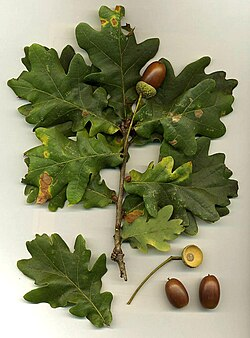
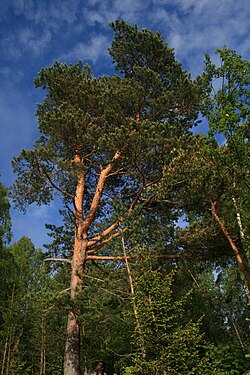
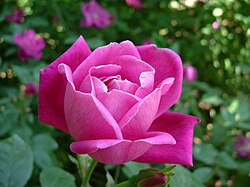
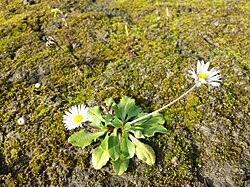
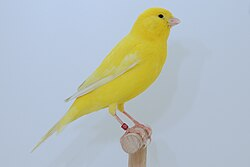
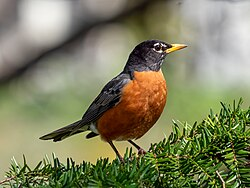
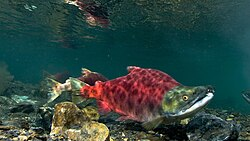
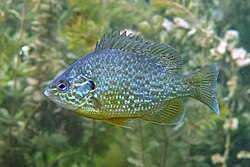

MSE: 0.22672 → 0.00951


In [6]:
seed, epochs, learning_rate = 0, 500, 0.1
model = SemanticNetwork(seed)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
order_rng = np.random.default_rng(seed + 10000)
identity = torch.eye(15, dtype=torch.float64)
leaves = ['oak', 'pine', 'rose', 'daisy', 'canary', 'robin', 'salmon', 'sunfish']
indices = [concepts.index(item) for item in leaves]
view = TrainingView(leaves, indices)
losses, snapshots = [], {}

for epoch in range(epochs + 1):
    if epoch:
        for i in order_rng.permutation(len(X)):
            learn_one(model, optimizer, X[i], R[i], Y[i])
    with torch.no_grad():
        prediction = model(X, R)
        losses.append((prediction - Y).square().mean().item())
        snapshots[epoch] = model.representations(identity).numpy().copy()
    if epoch % 25 == 0 or epoch == epochs:
        view.update(snapshots, losses)

view.save()
print(f'MSE: {losses[0]:.5f} → {losses[-1]:.5f}')

### Mean squared error

MSE is the average squared difference between predictions and targets across all training outputs; lower values indicate more accurate predictions.

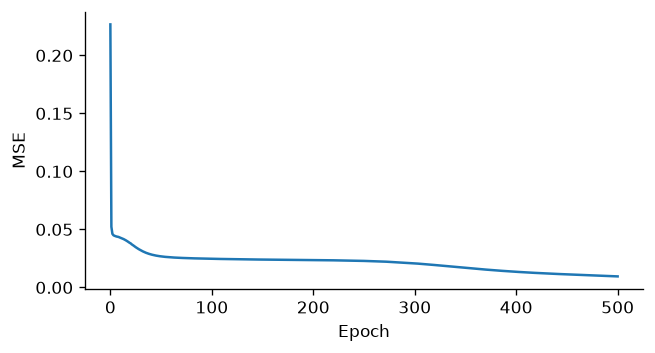

In [7]:
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()

The dendrograms below compare representations at epochs 25, 200, and 500 on the same distance scale. Concepts that merge at a smaller distance have more similar representations. Look first at oak–pine and robin–canary, then at the broader plant and animal groups.

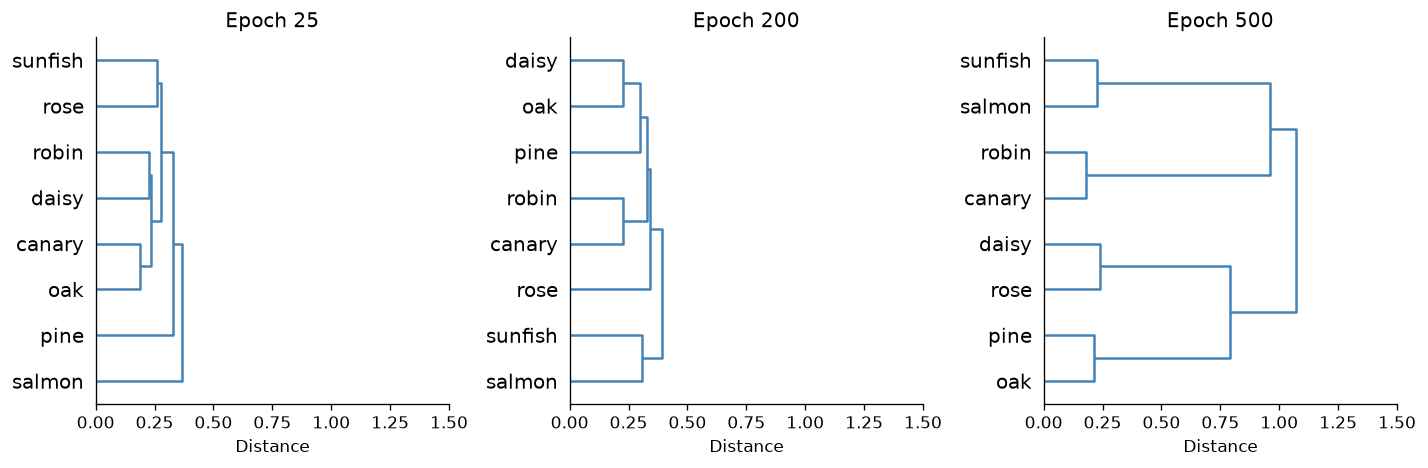

In [8]:
leaves = ['oak', 'pine', 'rose', 'daisy', 'canary', 'robin', 'salmon', 'sunfish']
indices = [concepts.index(item) for item in leaves]

plot_clusters({e: snapshots[e] for e in [25, 200, 500]}, indices, leaves)

Similar representations do not guarantee that every fact has been learned. The table shows the network's final predictions for each concept under the `can` relation. Compare the two birds' `fly` and `sing` outputs with the targets above.

In [9]:
predictions = pd.DataFrame(prediction.numpy(), index=targets.index, columns=targets.columns)
rows = [f'{item} | can' for item in leaves]
predictions.loc[rows, ['grow', 'move', 'swim', 'fly', 'sing']].round(2)

,grow,move,swim,fly,sing
oak | can,0.90,0.06,0.00,0.13,0.09
pine | can,0.89,0.06,0.00,0.13,0.09
rose | can,0.91,0.13,0.04,0.06,0.10
daisy | can,0.92,0.11,0.02,0.06,0.10
canary | can,0.98,0.90,0.19,0.76,0.26
robin | can,0.98,0.91,0.21,0.76,0.28
salmon | can,0.96,0.92,0.77,0.13,0.12
sunfish | can,0.96,0.94,0.77,0.17,0.13
